2025-11-24 16:00:01.069005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763996401.077259 3784242 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763996401.079742 3784242 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-24 16:00:01.089061: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


전체 데이터 형태: (10000, 67)
학습 데이터 X 형태: (8989, 10, 67)
학습 데이터 Y 형태: (8989, 64)


I0000 00:00:1763996404.286347 3784242 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1182 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:2b:00.0, compute capability: 8.6


학습 시작...
Epoch 1/50


I0000 00:00:1763996405.481801 3784813 cuda_dnn.cc:529] Loaded cuDNN version 90101


281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0098 - val_loss: 0.0032
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056 - val_loss: 0.0033
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0048 - val_loss: 0.0031
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0047 - val_loss: 0.0030
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0031
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0045 - val_loss: 0.0030
Epoch 9/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - val_loss: 0.0030
Epoch 10/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - val_loss: 0.0029
Epoch 11/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - val_loss: 0.0029
Epoch 12/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.

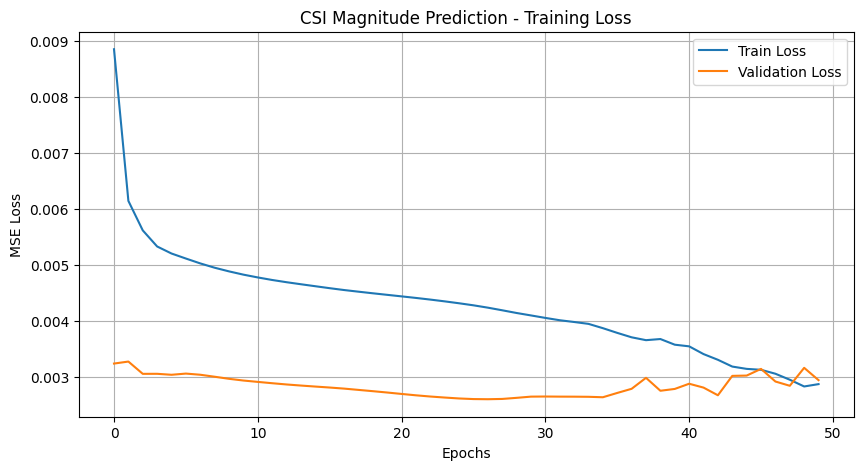

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


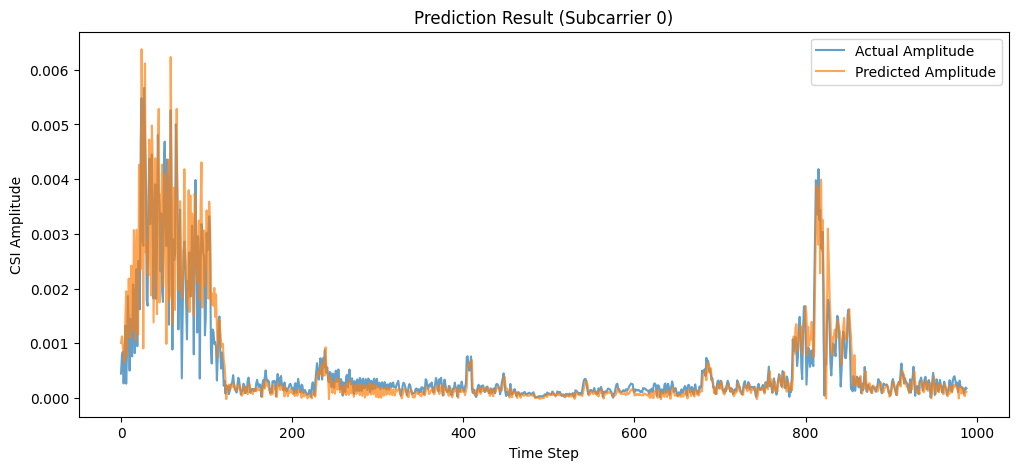

In [2]:
import scipy.io as sio
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt
import os

# ==========================================
# 1) 데이터 로드
# ==========================================
mat_path = "csi_dataset.mat"  # 로컬 파일 경로

if not os.path.exists(mat_path):
    print(f"에러: 파일을 찾을 수 없습니다. 경로를 확인하세요: {mat_path}")
else:
    # 데이터 읽기
    data = sio.loadmat(mat_path)
    csi = data["csi"]        # (N, 64, 1, 1) complex
    rx_pos = data["rx_pos"]  # (N, 3)

    N, F, _, _ = csi.shape   # N: 샘플 수, F: 64 서브캐리어

    # ==========================================
    # 2) [핵심 수정] CSI -> 진폭(Magnitude) 변환
    # ==========================================
    csi = csi.reshape(N, F)
    
    # (기존) 실수/허수 분리 -> (변경) 절댓값(진폭) 계산
    # np.abs()는 복소수의 크기(Magnitude)를 구해줍니다. 위상 노이즈가 제거됩니다.
    csi_amp = np.abs(csi)    # (N, 64)

    # Feature 결합: [진폭(64), 위치(3)] = 67차원
    features = np.concatenate([csi_amp, rx_pos], axis=1)
    
    print(f"전체 데이터 형태: {features.shape}")  # (N, 67) 확인

    # 3) Train / Test 분할 (90% / 10%)
    split_percentage = 0.9
    split_point = round(N * split_percentage)

    train_feat = features[:split_point]
    test_feat = features[split_point:]

    # 4) 스케일링 (0~1 범위로 정규화)
    scaler = MinMaxScaler()
    scaler.fit(train_feat)

    scaled_train = scaler.transform(train_feat)
    scaled_test  = scaler.transform(test_feat)

    # 5) 시계열 윈도우 생성 함수
    def timeseries_preprocessing(scaled_train, scaled_test, lags):
        # 입력(X): 과거 lags개 시점의 [진폭+위치] (67차원)
        # 출력(Y): 다음 시점의 [진폭]만 (64차원)
        
        # Train
        X_tr, Y_tr = [], []
        for t in range(len(scaled_train) - lags - 1):
            X_tr.append(scaled_train[t : t+lags, :])
            Y_tr.append(scaled_train[t+lags, :64]) # 앞 64개(진폭)만 예측 타겟

        # Test
        X_te, Y_te = [], []
        for t in range(len(scaled_test) - lags - 1):
            X_te.append(scaled_test[t : t+lags, :])
            Y_te.append(scaled_test[t+lags, :64])

        return np.array(X_tr), np.array(Y_tr), np.array(X_te), np.array(Y_te)

    # 윈도우 크기 설정
    lags = 10
    
    # 데이터셋 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(scaled_train, scaled_test, lags)

    print("학습 데이터 X 형태:", X_train.shape)  # (samples, 10, 67)
    print("학습 데이터 Y 형태:", Y_train.shape)  # (samples, 64) -> 128에서 64로 줄어듦

    # 6) LSTM 모델 정의
    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64 (진폭 개수)

    model = Sequential()
    # Input 레이어 명시 (권장 방식)
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(256))           # 뇌세포 256개
    model.add(Dense(output_dim))   # 출력 64개 (진폭 예측)

    model.compile(optimizer='adam', loss='mse')

    # 7) 학습 시작
    print("학습 시작...")
    history = model.fit(
        X_train, Y_train,
        epochs=50,
        validation_data=(X_test, Y_test),
        shuffle=False,
        verbose=1
    )

    # 8) 결과 그래프 (Loss)
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('CSI Magnitude Prediction - Training Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 9) 예측 결과 시각화 (첫 번째 서브캐리어)
    # 예측 수행
    Y_pred_scaled = model.predict(X_test)
    
    # 스케일링 복원 (진폭 부분만)
    # 전체 scaler에서 앞 64개(진폭) 정보만 가져와서 복원용 scaler 생성
    scaler_amp = MinMaxScaler()
    scaler_amp.min_ = scaler.min_[:64]
    scaler_amp.scale_ = scaler.scale_[:64]
    
    # 실제값 복원
    Y_true = (Y_test - scaler_amp.min_) / scaler_amp.scale_
    Y_pred = (Y_pred_scaled - scaler_amp.min_) / scaler_amp.scale_

    # 그래프: 0번 서브캐리어의 진폭 비교
    plt.figure(figsize=(12, 5))
    plt.plot(Y_true[:, 0], label='Actual Amplitude', alpha=0.7)
    plt.plot(Y_pred[:, 0], label='Predicted Amplitude', alpha=0.7)
    plt.title('Prediction Result (Subcarrier 0)')
    plt.xlabel('Time Step')
    plt.ylabel('CSI Amplitude')
    plt.legend()
    plt.show()

Experiment A: LSTM Units (Lag=10)
Units=32 -> Accuracy: 64.00%
Units=64 -> Accuracy: 64.11%
Units=128 -> Accuracy: 63.68%
Units=256 -> Accuracy: 63.61%
Units=512 -> Accuracy: 63.98%

Experiment B: Lags (Units=256)
Lag=3 -> Accuracy: 62.04%
Lag=5 -> Accuracy: 62.31%
Lag=10 -> Accuracy: 62.87%
Lag=15 -> Accuracy: 63.13%
Lag=20 -> Accuracy: 64.66%


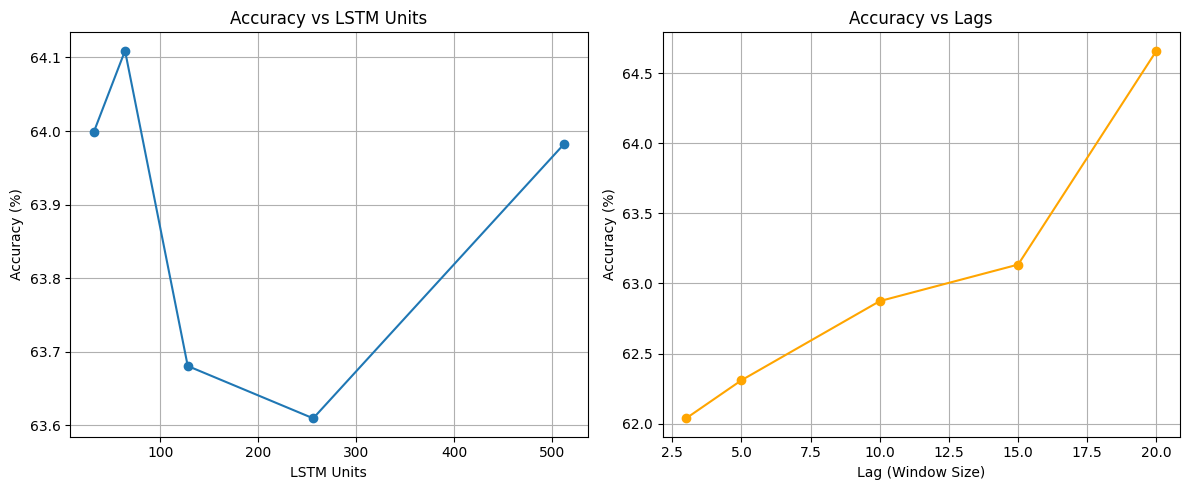

In [3]:
from sklearn import metrics
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

# -------------------------------------------------------
# 1. 정확도 계산 함수 (진폭 64개에 맞게 수정)
# -------------------------------------------------------
def make_amp_scaler(scaler_all):
    """67차원(진폭64+위치3) scaler에서 앞 64개(진폭)만 떼서 복원용 scaler 생성"""
    scaler_amp = MinMaxScaler()
    # 64개 Feature에 대한 스케일 정보만 복사
    scaler_amp.min_        = scaler_all.min_[:64].copy()
    scaler_amp.scale_      = scaler_all.scale_[:64].copy()
    scaler_amp.data_min_   = scaler_all.data_min_[:64].copy()
    scaler_amp.data_max_   = scaler_all.data_max_[:64].copy()
    scaler_amp.data_range_ = scaler_all.data_range_[:64].copy()
    scaler_amp.n_features_in_ = 64
    scaler_amp.feature_range  = scaler_all.feature_range
    return scaler_amp

def get_accuracy(model, X, Y, scaler_all):
    # 예측
    Y_pred_scaled = model.predict(X, verbose=0)
    
    # 스케일링 복원
    scaler_amp = make_amp_scaler(scaler_all)
    Y_true = scaler_amp.inverse_transform(Y)
    Y_pred = scaler_amp.inverse_transform(Y_pred_scaled)
    
    # 정확도 계산 (1 - MAE/Mean) * 100
    mae = metrics.mean_absolute_error(Y_true, Y_pred)
    mean_val = np.mean(Y_true)
    accuracy = (1 - mae / mean_val) * 100
    return accuracy

# -------------------------------------------------------
# 2. 모델 생성 및 학습 함수
# -------------------------------------------------------
def run_experiment(units, lags, scaled_train, scaled_test):
    # 데이터셋 생성
    X_train, Y_train, X_test, Y_test = timeseries_preprocessing(
        scaled_train, scaled_test, lags
    )
    
    n_features = X_train.shape[2]  # 67
    output_dim = Y_train.shape[1]  # 64
    
    # 모델 정의
    model = Sequential()
    model.add(Input(shape=(lags, n_features)))
    model.add(LSTM(units))
    model.add(Dense(output_dim))
    model.compile(optimizer='adam', loss='mse')
    
    # 학습 (간단히 15 에포크만)
    model.fit(X_train, Y_train, epochs=15, batch_size=32, verbose=0, shuffle=False)
    
    # 정확도 측정
    acc = get_accuracy(model, X_test, Y_test, scaler)
    return acc

# =======================================================
# 실험 A: LSTM 유닛 수 변화에 따른 정확도
# =======================================================
units_list = [32, 64, 128, 256, 512]
fixed_lag = 10
acc_units = []

print(f"Experiment A: LSTM Units (Lag={fixed_lag})")
for u in units_list:
    acc = run_experiment(u, fixed_lag, scaled_train, scaled_test)
    acc_units.append(acc)
    print(f"Units={u} -> Accuracy: {acc:.2f}%")

# =======================================================
# 실험 B: 윈도우 크기(Lag) 변화에 따른 정확도
# =======================================================
lags_list = [3, 5, 10, 15, 20]
fixed_unit = 256
acc_lags = []

print(f"\nExperiment B: Lags (Units={fixed_unit})")
for l in lags_list:
    acc = run_experiment(fixed_unit, l, scaled_train, scaled_test)
    acc_lags.append(acc)
    print(f"Lag={l} -> Accuracy: {acc:.2f}%")

# =======================================================
# 결과 시각화
# =======================================================
plt.figure(figsize=(12, 5))

# 그래프 1: Units
plt.subplot(1, 2, 1)
plt.plot(units_list, acc_units, marker='o', linestyle='-')
plt.title('Accuracy vs LSTM Units')
plt.xlabel('LSTM Units')
plt.ylabel('Accuracy (%)')
plt.grid(True)

# 그래프 2: Lags
plt.subplot(1, 2, 2)
plt.plot(lags_list, acc_lags, marker='o', linestyle='-', color='orange')
plt.title('Accuracy vs Lags')
plt.xlabel('Lag (Window Size)')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()